In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42
matplotlib.rcParams["font.family"] = "Arial"

In [2]:
# data
df_fcz = pd.DataFrame({
    "Model": ["Null", "Mut", "Filt", "Add", "MultFilt", "FiltAdd", "MultAdd", "Full"],
    "R2": [0.97216, 0.97256, 0.97307, 0.97400, 0.97312, 0.97481, 0.97404, 0.97538],
    "k": [4, 5, 5, 5, 6, 6, 6, 7],
    "AICc": [-105.12, -102.75, -103.36, -104.48, -100.37, -102.44, -101.48, -99.868],
})

df_pz = pd.DataFrame({
    "Model": ["Null", "Mut", "Filt", "Add", "MultFilt", "FiltAdd", "MultAdd", "Full"],
    "R2": [0.95734, 0.95807, 0.95763, 0.96329, 0.95811, 0.96344, 0.96381, 0.96450],
    "k": [4, 5, 5, 5, 6, 6, 6, 7],
    "AICc": [-91.459, -89.185, -88.857, -93.440, -86.166, -90.518, -90.849, -88.156],
})

In [3]:
# model 
params = ["Additive", "Multiplicative", "External filtering"]

model_flags = {
    "Null":     [0, 0, 0],
    "Add":      [1, 0, 0],
    "Mut":      [0, 1, 0],
    "Filt":     [0, 0, 1],
    "MultAdd":  [1, 1, 0],
    "MultFilt": [0, 1, 1],
    "FiltAdd":  [1, 0, 1],
    "Full":     [1, 1, 1],
}

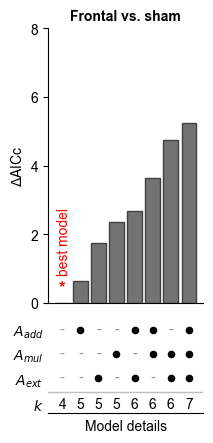

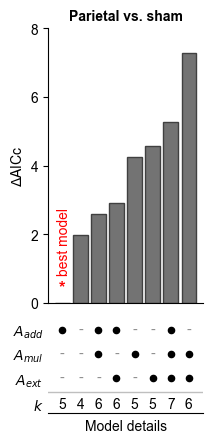

In [6]:
# plot

def plot_aicc_model_comparison(df, title, filename):
    df = df.copy()
    df["DeltaAICc"] = df["AICc"] - df["AICc"].min()
    df = df.sort_values("DeltaAICc").reset_index(drop=True)

    flag_matrix = np.array([model_flags[m] for m in df["Model"]]).T

    fig = plt.figure(figsize=(2, 5))

    gs = fig.add_gridspec(
        2, 1,
        height_ratios=[4, 1.5],
        hspace=0.04
    )

    ax = fig.add_subplot(gs[0])
    ax_mat = fig.add_subplot(gs[1], sharex=ax)

    x = np.arange(len(df))

    # Bar plot
    ax.bar(
        x,
        df["DeltaAICc"],
        color="0.45",
        edgecolor="0.25"
    )

    ax.set_ylabel(r"$\Delta$AICc", fontsize=10)
    ax.set_title(title, fontsize=10, fontweight="bold")
    #ax.set_ylim(0, max(df["DeltaAICc"]) * 1.25 if max(df["DeltaAICc"]) > 0 else 1)
    ax.set_ylim(0, 8)
    ax.set_yticks(np.arange(0, 9, 2))

    # Best model label
    best_x = df["DeltaAICc"].idxmin()

    ax.text(
        best_x,
        0.25,
        "*",
        color="red",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        best_x - 0.28,
        0.8,
        "best model",
        rotation=90,
        color="red",
        fontsize=10,
        va="bottom"
    )

    ax.set_xticks([])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Model details matrix
    k_y = -1.05
    ax_mat.set_ylim(-1.45, len(params) - 0.2)

    for i, param in enumerate(params):
        y = len(params) - 1 - i

        for j in range(len(df)):
            if flag_matrix[i, j] == 1:
                ax_mat.scatter(
                    j,
                    y,
                    s=20,
                    color="black"
                )
            else:
                ax_mat.text(
                    j,
                    y,
                    "-",
                    ha="center",
                    va="center",
                    color="0.55",
                    fontsize=10
                )

    # Divider above k row
    ax_mat.axhline(
        -0.55,
        color="0.75",
        lw=1
    )

    # k row
    for j, kval in enumerate(df["k"]):
        ax_mat.text(
            j,
            k_y,
            str(kval),
            ha="center",
            va="center",
            fontsize=10
        )

    ax_mat.set_yticks([2, 1, 0, k_y])
    ax_mat.set_yticklabels(
        [r"$A_{add}$", r"$A_{mul}$", r"$A_{ext}$", r"$k$"],
        fontsize=10
    )

    ax_mat.tick_params(
        axis="x",
        which="both",
        bottom=False,
        top=False,
        labelbottom=False
    )

    ax_mat.set_xlabel("Model details", fontsize=10)

    ax_mat.spines["top"].set_visible(False)
    ax_mat.spines["right"].set_visible(False)
    ax_mat.spines["left"].set_visible(False)
    ax_mat.tick_params(axis="y", length=0)

    fig.canvas.draw()

    fig.savefig(
        filename,
        dpi=300,
        facecolor="white",
        bbox_inches="tight"
    )

    plt.show()

    return df

# Generate figures --------------------

df_fcz_ordered = plot_aicc_model_comparison(
    df_fcz,
    "Frontal vs. sham",
    "AICc_tDCS_frontal_vs_sham.pdf"
)

df_pz_ordered = plot_aicc_model_comparison(
    df_pz,
    "Parietal vs. sham",
    "AICc_tDCS_parietal_vs_sham.pdf"
)